# MetaboLights - Data Pipeline
MetaboLights: https://www.ebi.ac.uk/metabolights/

## STEP: Metadata Extraction

In [ ]:
import json
import os

from bcbio import isatab

METABOLIGHTS_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights"
)

METABOLIGHTS_RAW_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "raw"
)

METABOLIGHTS_RAW_HUMAN_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "raw_human"
)


study_metadata = {}

for subfolder in os.listdir(METABOLIGHTS_RAW_HUMAN_DATA_PATH):
    print(f"Extracting data from {subfolder}...")
    subfolder_path = os.path.join(METABOLIGHTS_RAW_HUMAN_DATA_PATH, subfolder)

    try:
        # Parse using isatab parser
        rec = isatab.parse(subfolder_path)

    except UnicodeDecodeError as error:
        print(f"UnicodeDecodeError in folder {subfolder}: {str(error)}")
        continue  # Skip this subfolder and continue to the next one
    except KeyError as error:
        print(f"KeyError in folder {subfolder}: {str(error)}")
        continue
    except ValueError as error:
        print(f"ValueError in folder {subfolder}: {str(error)}")
        continue
    except AssertionError as error:
        print(f"AssertionError in folder {subfolder}: {str(error)}")
        continue
    
    study = rec.studies[0]

    # Extract organism information for the study
    sample_names = study.nodes.keys()
    sample_organism_list = []

    for sample in sample_names:
        try:
            sample_organism = study.nodes[sample].metadata['Characteristics[Organism]'][0][0]
        except KeyError:
            sample_organism = study.nodes[sample].metadata['Characteristics[Organism part]'][0][0]
        
        sample_organism_list.append(sample_organism)

    unique_organism_list = list(set(sample_organism_list))
    sorted_organism_list = sorted(unique_organism_list)

    # Extract organism part information for the study
    sample_organism_part_list = []

    for sample in sample_names:
        sample_organism_part = study.nodes[sample].metadata['Characteristics[Organism part]'][0][0]

        sample_organism_part_list.append(sample_organism_part)

    unique_organism_part_list = list(set(sample_organism_part_list))
    sorted_organism_part_list = sorted(unique_organism_part_list)

    # Extract patient/sample information for the study
    samples_dict = {}
    
    for sample in sample_names:
        sample_dict = {}
        sample_name = study.nodes[sample].metadata["Sample Name"][0]

        # Sample metadata
        sample_metadata = study.nodes[sample].metadata
        meta_data_keys = sample_metadata.keys()

        for key in meta_data_keys:
            if isinstance(sample_metadata[key][0], str):
                sample_dict[key] = sample_metadata[key][0]
            else:
                sample_dict[key] = sample_metadata[key][0][0]

        samples_dict[sample_name] = sample_dict

    study_dict = {}
    study_dict["Study Title"] = study.metadata["Study Title"]
    study_dict["Study Organism"] = sorted_organism_list
    study_dict["Study Organism Part"] = sorted_organism_part_list
    study_dict["Study Submission Date"] = study.metadata["Study Submission Date"]
    study_dict["Study Public Release Date"] = study.metadata["Study Public Release Date"]
    study_dict["Design Descriptors"] = [descriptor for descriptor in study.design_descriptors]
    study_dict["Factors"] = [factor for factor in study.factors]
    study_dict["Samples"] = samples_dict

    study_metadata[study.metadata["Study Identifier"]] = study_dict

# Convert the dictionary to a JSON string
json_string = json.dumps(study_metadata, indent=2)

# Save the JSON string to a file
metadata_path = os.path.join(METABOLIGHTS_DATA_PATH, "metabolights_human_metadata.json")
with open(metadata_path, "w") as json_file:
    json_file.write(json_string)

print(f"JSON data saved to {metadata_path}")

## STEP: Extract Homo Sapiens studies

In [ ]:
import json
import os
import shutil

METABOLIGHTS_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights"
)

METABOLIGHTS_RAW_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "raw"
)

METABOLIGHTS_RAW_HUMAN_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "raw_human"
)


# Create the raw human directory if it doesn't exist
if not os.path.exists(METABOLIGHTS_RAW_HUMAN_DATA_PATH):
    os.makedirs(METABOLIGHTS_RAW_HUMAN_DATA_PATH)

metadata_path = os.path.join(METABOLIGHTS_DATA_PATH, "metabolights_metadata.json")
# Load the JSON metadata file
with open(metadata_path, "r") as json_file:
    metadata = json.load(json_file)

# Iterate through study IDs in the metadata
for study_id, study_info in metadata.items():
    study_organisms = study_info.get("Study Organism", [])
    
    # Check if "Homo sapiens" is in the list of study organisms
    if "Homo sapiens" in study_organisms:
        source_study_path = os.path.join(METABOLIGHTS_RAW_DATA_PATH, study_id)
        destination_study_path = os.path.join(METABOLIGHTS_RAW_HUMAN_DATA_PATH, study_id)
        
        try:
            # Move the study folder to the raw_human directory
            shutil.move(source_study_path, destination_study_path)
            print(f"Study {study_id} moved to {destination_study_path}")
        except FileNotFoundError as error:
            print(f"FileNotFoundError in folder {source_study_path}: {str(error)}")
            continue

print("Processing completed.")

## STEP: Seperate Only Homo Sapiens Studies

In [ ]:
import json
import os
import shutil

METABOLIGHTS_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights"
)

METABOLIGHTS_RAW_HUMAN_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "raw_human"
)

METABOLIGHTS_RAW_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "raw_human_only"
)


# Create the raw human only directory if it doesn't exist
if not os.path.exists(METABOLIGHTS_RAW_HUMAN_ONLY_DATA_PATH):
    os.makedirs(METABOLIGHTS_RAW_HUMAN_ONLY_DATA_PATH)

metadata_path = os.path.join(METABOLIGHTS_DATA_PATH, "metabolights_human_metadata.json")
# Load the JSON metadata file
with open(metadata_path, "r") as json_file:
    metadata = json.load(json_file)

# Iterate through study IDs in the metadata
for study_id, study_info in metadata.items():
    study_organisms = study_info.get("Study Organism", [])
    
    # Check if "Homo sapiens" is in the list of study organisms
    if "Homo sapiens" in study_organisms and len(study_organisms) == 1:
        source_study_path = os.path.join(METABOLIGHTS_RAW_HUMAN_DATA_PATH, study_id)
        destination_study_path = os.path.join(METABOLIGHTS_RAW_HUMAN_ONLY_DATA_PATH, study_id)
        
        try:
            # Move the study folder to the raw_human directory
            shutil.move(source_study_path, destination_study_path)
            print(f"Study {study_id} moved to {destination_study_path}")
        except FileNotFoundError as error:
            print(f"FileNotFoundError in folder {source_study_path}: {str(error)}")
            continue

print("Processing completed.")

## STEP: Parser

In [ ]:
import os

import pandas as pd


METABOLIGHTS_RAW_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "raw_human_only"
)

METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "unmapped_human_only"
)


def extract_patient_names(df: pd.DataFrame):
    for i, column in enumerate(df.columns):
        if column == "smallmolecule_abundance_std_error_sub":
            return df.columns[i + 1 :]


# Create the unmapped directory if it doesn't exist
if not os.path.exists(METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH):
    os.makedirs(METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH)

# Iterate through subfolders in the raw directory
for subfolder in os.listdir(METABOLIGHTS_RAW_HUMAN_ONLY_DATA_PATH):
    subfolder_path = os.path.join(METABOLIGHTS_RAW_HUMAN_ONLY_DATA_PATH, subfolder)

    # Create the subfolder in the unmapped directory if it doesn't exist
    unmapped_subfolder_path = os.path.join(METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH, subfolder)
    if not os.path.exists(unmapped_subfolder_path):
        os.makedirs(unmapped_subfolder_path)

    # Iterate through .tsv files in the subfolder
    for filename in os.listdir(subfolder_path):
        if filename.endswith(".tsv") and filename[:2] == "m_":
            try:
                tsv_path = os.path.join(subfolder_path, filename)
                print(f"Parsing file {tsv_path}")

                # Read the TSV file into a DataFrame
                raw_df = pd.read_csv(tsv_path, sep="\t")

                # Extract unique metabolite names
                metabolite_names = raw_df["metabolite_identification"]
                metabolite_names = [metabolite for metabolite in metabolite_names]
                # Create columns
                columns = list(metabolite_names)
                columns.insert(0, "Factors")
                study_df = pd.DataFrame(columns=columns)

                # Get patient names/labels
                patient_names = extract_patient_names(raw_df)
                study_df["Factors"] = patient_names

                # Fill metabolite concentration values for each patient
                for patient_index, patient in enumerate(patient_names):
                    patient_mconc = raw_df[patient]
                    for metabolite_index, metabolite in enumerate(metabolite_names):
                        study_df.loc[patient_index, metabolite] = patient_mconc[metabolite_index]

                # Create the parsed CSV file in the subfolder of the unmapped directory
                parsed_filename = os.path.splitext(filename)[0]
                parsed_csv_path = os.path.join(unmapped_subfolder_path, f"{parsed_filename}.csv")
                study_df.to_csv(parsed_csv_path, index=False)
                print(f"Parsed data saved to: {parsed_csv_path}")
                
            except TypeError as error:
                print(f"TypeError in file {filename}: {str(error)}")
                continue

            except KeyError as error:
                print(f"KeyError in file {filename}: {str(error)}")
                continue

            except UnicodeDecodeError as error:
                print(f"UnicodeDecodeError in file {filename}: {str(error)}")
                continue

## Filter Homo Sapiens Studies
* Drop uncaptured metabolites. ex: Unnamed: 1, blank metabolite names ✅
* Those with a metabolite number of less than 50 will be discarded. ✅
* If there are two or more identical metabolite names in the same study, these two values ​​will be averaged. ✅

In [ ]:
import os

import pandas as pd

METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "unmapped_human_only"
)


def average_similar_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate the average for columns with similar names, and return a DataFrame with averaged columns.

    Args:
        df (DataFrame): The input DataFrame.

    Returns:
        DataFrame: A DataFrame with columns containing averaged values.
    """
    # Create a dictionary to store the columns to be averaged
    columns_to_average = {}

    # Iterate through columns in the DataFrame
    for column in df.columns:
        base_column_name = column.split(".")[
            0
        ]  # Get the base column name (e.g., isoleucine from isoleucine.1)

        # Check if the base column name is already in the dictionary
        if base_column_name in columns_to_average:
            # Add the current column to the list of columns to be averaged
            columns_to_average[base_column_name].append(column)
        else:
            # Create a new list for the base column name and add the current column to it
            columns_to_average[base_column_name] = [column]

    # Iterate through the dictionary and calculate the average for each group of columns
    for base_column_name, columns in columns_to_average.items():
        if base_column_name != "Factors":
            df[base_column_name] = df[columns].mean(axis=1)  # Calculate the average

        if len(columns) > 1:
            drop_cols = columns[1:]
            df.drop(columns=drop_cols, inplace=True)  # Drop the original columns

    return df

def check_empty_dataframe(df: pd.DataFrame) -> bool:
    """
    Check if a DataFrame contains 50% or more missing values (NaNs).

    Args:
        df (pd.DataFrame): The DataFrame to be checked for missing values.

    Returns:
        bool: True if the DataFrame contains 50% or more missing values, False otherwise.
    """
    # Create a boolean mask where True represents missing values
    missing_mask = df.isna()

    # Count the number of True values (missing values)
    missing_count = missing_mask.sum().sum()  # Sum twice to count all missing values

    # Calculate the percentage of missing values
    total_cells = df.size
    percentage_missing = (missing_count / total_cells) * 100

    return percentage_missing >= 50


# Iterate through subfolders in the unmapped data path
for subfolder in os.listdir(METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH):
    subfolder_path = os.path.join(METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH, subfolder)

    if os.path.isdir(subfolder_path):
        print(f"Processing folder {subfolder}....")
        csv_files = [
            filename
            for filename in os.listdir(subfolder_path)
            if filename.endswith(".csv")
        ]

        # Iterate through csv files in the subfolder
        for filename in csv_files:
            csv_path = os.path.join(subfolder_path, filename)
            df = pd.read_csv(csv_path)

            # Uncaptured metabolites
            df = df.loc[:, ~df.columns.str.contains("Unnamed")]
            df = df.loc[:, ~df.columns.str.contains("unknown")]
            df = df.loc[:, ~df.columns.str.contains("Unknown")]
            df = df.loc[:, ~df.columns.str.contains("unidentified")]

            # Average columns with similar names
            df = average_similar_columns(df)

            # Drop rows where the entire row is empty
            df.dropna(axis=0, how="all", inplace=True, subset=df.columns[1:])  # Exclude the first column

            # Check if the DataFrame is contains 50% or more missing values or < 50 metabolites
            if check_empty_dataframe(df) or len(df.columns) < 50:
                print(f"Deleting file {filename}.")
                os.remove(csv_path)
            else:
                df.to_csv(csv_path, index=False)
                print(f"Processed data saved to: {csv_path}")

        if not os.listdir(subfolder_path):
            print(f"Deleting empty subfolder: {subfolder}")
            os.rmdir(subfolder_path)

print("DONE !")

## STEP: Random Fill Folders
* Fill missing values randomly between col.min_val and col.max_val.
* If a column is completely empty, remove that column. ✅

In [ ]:
import os

import numpy as np
import pandas as pd


def random_fill_folders(input_path: str, output_path: str) -> None:
    """
    Traverse subfolders in the input_path, read CSV files, fill missing values with random float values
    within the range of their respective columns, and output to the output_path.

    Args:
        input_path (str): The path to the directory containing subfolders with CSV files.
        output_path (str): The path to the output directory for CSV files with missing values filled.
    """
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    for subfolder in os.listdir(input_path):
        subfolder_path = os.path.join(input_path, subfolder)

        if os.path.isdir(subfolder_path):
            csv_files = [
                filename
                for filename in os.listdir(subfolder_path)
                if filename.endswith(".csv")
            ]

            for filename in csv_files:
                csv_path = os.path.join(subfolder_path, filename)
                df = pd.read_csv(csv_path)

                # Remove completely empty columns (contain only NaN values)
                df.dropna(axis=1, how='all', inplace=True)

                # Iterate through columns and fill missing values (including 0.0) with random values within their range
                for column in df.columns:
                    if column != "Factors":  # Skip the "Factors" column
                        min_value = df[column].min()
                        max_value = df[column].max()
                        missing_mask = (df[column].isna()) | (df[column] == 0.0)
                        num_missing = missing_mask.sum()

                        random_values = np.random.uniform(min_value, max_value, num_missing)
                        df.loc[missing_mask, column] = random_values

                # Define the output path for the CSV file with missing values filled
                output_csv_path = os.path.join(output_path, subfolder, filename)

                # Ensure the output subfolder exists
                os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)

                # Write the DataFrame with filled missing values to the output CSV file
                df.to_csv(output_csv_path, index=False)

                print(f"CSV file with missing values filled saved to: {output_csv_path}")


# Example usage
METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "unmapped_human_only"
)

METABOLIGHTS_RANDOM_FILLED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "random_filled_human_only"
)

random_fill_folders(
    input_path=METABOLIGHTS_UNMAPPED_HUMAN_ONLY_DATA_PATH,
    output_path=METABOLIGHTS_RANDOM_FILLED_HUMAN_ONLY_DATA_PATH,
)

## STEP: Normalize data

In [ ]:
import os

import pandas as pd


def min_max_scaling(series: pd.Series):
    """
    Apply min-max scaling to a Pandas Series.

    Args:
        series (pd.Series): The Series to be scaled.

    Returns:
        pd.Series: The scaled Series.
    """
    min_val = series.min()
    max_val = series.max()

    return (series - min_val) / (max_val - min_val)


def normalize_folders(
    input_path: str, output_path: str, verbose: bool = False
) -> None:
    """
    Traverse subfolders in the input_path, read CSV files, normalize DataFrames with min-max scaling.
    And output to the output_path.

    Args:
        input_path (str): The path to the directory containing subfolders with CSV files.
        output_path (str): The path to the output directory for normalized CSV files.
    """
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    for subfolder in os.listdir(input_path):
        subfolder_path = os.path.join(input_path, subfolder)

        if os.path.isdir(subfolder_path):
            csv_files = [
                filename
                for filename in os.listdir(subfolder_path)
                if filename.endswith(".csv")
            ]

            for filename in csv_files:
                print(f"Normalizing file: {filename}")
                csv_path = os.path.join(subfolder_path, filename)
                df = pd.read_csv(csv_path)

                # Skip the "Factors" column for normalization
                columns_to_normalize = [col for col in df.columns if col != "Factors"]

                # Normalize the selected columns using min-max scaling
                df[columns_to_normalize] = df[columns_to_normalize].apply(
                    min_max_scaling
                )

                output_csv_path = os.path.join(output_path, subfolder, filename)
                os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
                df.to_csv(output_csv_path, index=False)

                if verbose:
                    print(f"Normalized data saved to: {output_csv_path}")


# Example usage
METABOLIGHTS_RANDOM_FILLED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "random_filled_human_only"
)

METABOLIGHTS_NORMALIZED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "normalized_human_only"
)

normalize_folders(
    input_path=METABOLIGHTS_RANDOM_FILLED_HUMAN_ONLY_DATA_PATH,
    output_path=METABOLIGHTS_NORMALIZED_HUMAN_ONLY_DATA_PATH,
    verbose=True,
)

## STEP: Create STUDY.CSV files
* Merge sub-files within study folder.
* In positive and negative studies (in different files), if the same metabolites have different values, the maximum value will be taken (element-wise).✅
* Connect study metabolites based on patients

In [ ]:
import os
import shutil

import pandas as pd


def merge_and_resolve_duplicates(dataframes, merge_column: str) -> pd.DataFrame:
    """
    Merge multiple DataFrames based on a common column and resolve duplicate columns by
    keeping the maximum value element-wise.

    Args:
        dataframes (list of pd.DataFrame): List of DataFrames to be merged.
        merge_column (str): The name of the common column to merge on.

    Returns:
        pd.DataFrame: The merged DataFrame with resolved duplicate columns.
    """
    # Start with the first DataFrame in the list
    merged_df = dataframes[0]

    # Convert the "Factors" column to a common data type (str)
    merged_df[merge_column] = merged_df[merge_column].astype(str)

    for df in dataframes[1:]:
        df[merge_column] = df[merge_column].astype(str)

        merged_df = pd.merge(
            merged_df, df, on=merge_column, how="outer", suffixes=("", "_y")
        )

        # Resolve duplicate columns by keeping the maximum value element-wise
        for column in merged_df.columns:
            if column != merge_column and column.endswith("_y"):
                merged_df[column[:-2]] = merged_df[[column, column[:-2]]].max(axis=1)

        # Drop the duplicate columns from the merge
        merged_df = merged_df.drop(
            columns=[column for column in merged_df.columns if column.endswith("_y")]
        )

    # Sort the columns alphabetically, excluding the first column ('Factors')
    columns = list(merged_df.columns)
    columns.remove(merge_column)
    columns.sort()
    columns = [merge_column] + columns
    merged_df = merged_df[columns]

    return merged_df


def create_study_csv(input_path: str, output_path: str, verbose: bool = False) -> None:
    """
    Merge CSV files within study subfolders with specific rules.

    Args:
        input_path (str): The path to the input directory containing subfolders with CSV files.
        output_path (str): The path to the output directory for merged CSV files.
        verbose (bool): Turn on/off command line prints.
    """
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    for subfolder in os.listdir(input_path):
        print(f"Trying to merge files in: {subfolder}")
        subfolder_path = os.path.join(input_path, subfolder)

        same_data_column_count = 0
        different_data_column_count = 0

        if os.path.isdir(subfolder_path):
            csv_files = [
                filename
                for filename in os.listdir(subfolder_path)
                if filename.endswith(".csv")
            ]

            # Check if there are more than 2 studies in a folder (POS, NEG, etc.)
            if len(csv_files) >= 2:
                data_frames = []

                for filename in csv_files:
                    csv_path = os.path.join(subfolder_path, filename)
                    df = pd.read_csv(csv_path)
                    data_frames.append(df)

                # Check if there are common column names in both DataFrames
                common_columns = set(data_frames[0].columns)
                for df in data_frames[1:]:
                    common_columns &= set(df.columns)

                if common_columns:
                    if verbose:
                        print(
                            "###########################################################################"
                        )
                        print(
                            f"Common columns found in subfolder {subfolder}: {common_columns}"
                        )
                        print(
                            f"Length of common columns found in subfolder {subfolder}: {len(common_columns)}"
                        )

                    # Check if data in the common columns are the same
                    for column in common_columns:
                        if column == "Factors":
                            continue
                        else:
                            are_columns_equal = all(
                                data_frames[0][column].equals(df[column])
                                for df in data_frames
                            )
                            if are_columns_equal:
                                # if verbose:
                                # print(f"Data in column {column} is same.")
                                same_data_column_count += 1
                                data_frames[0] = data_frames[0].drop(column, axis=1)

                            else:
                                different_data_column_count += 1
                                if verbose:
                                    print(f"Data in column {column} is not the same.")
                    if verbose:
                        print(f"Same data column count: {same_data_column_count}")
                        print(
                            f"Different data column count: {different_data_column_count}"
                        )

                merged_df = merge_and_resolve_duplicates(data_frames, "Factors")

                if not merged_df.empty:
                    merged_output_path = os.path.join(output_path, f"{subfolder}.csv")
                    merged_df.to_csv(merged_output_path, index=False)
                    print(f"Merged data saved to: {merged_output_path}")

            else:  # Single csv file in directory
                if verbose:
                    print(
                        f"Only one CSV file found in subfolder {subfolder}. Copying and renaming it..."
                    )
                # Copy the single CSV file and rename it as the subfolder name
                src_path = os.path.join(subfolder_path, csv_files[0])
                dst_path = os.path.join(output_path, f"{subfolder}.csv")
                shutil.copyfile(src_path, dst_path)
                
                if verbose:
                    print(f"File copied and renamed to: {dst_path}")


# Example usage
METABOLIGHTS_NORMALIZED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "normalized_human_only"
)

METABOLIGHTS_MERGED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "merged_human_only"
)

create_study_csv(
    input_path=METABOLIGHTS_NORMALIZED_HUMAN_ONLY_DATA_PATH,
    output_path=METABOLIGHTS_MERGED_HUMAN_ONLY_DATA_PATH,
    verbose=False,
)

## STEP: Fill randomly again after merge

In [ ]:
import os

import numpy as np
import pandas as pd


def fill_missing_with_random(input_path: str, output_path: str) -> None:
    """
    Traverse subfolders in the input_path, read CSV files, fill missing values with random float values
    within the range of their respective columns, and output to the output_path.

    Args:
        input_path (str): The path to the directory containing subfolders with CSV files.
        output_path (str): The path to the output directory for CSV files with missing values filled.
    """
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    if os.path.isdir(input_path):
        csv_files = [
            filename
            for filename in os.listdir(input_path)
            if filename.endswith(".csv")
        ]

        for filename in csv_files:
            csv_path = os.path.join(input_path, filename)

            # Read the CSV file into a DataFrame
            df = pd.read_csv(csv_path)

            # Remove completely empty columns (contain only NaN values)
            df.dropna(axis=1, how='all', inplace=True)

            # Iterate through columns and fill missing values (including 0.0) with random values within their range
            for column in df.columns:
                if column != "Factors":  # Skip the "Factors" column
                    min_value = df[column].min()
                    max_value = df[column].max()
                    missing_mask = (df[column].isna())
                    num_missing = missing_mask.sum()

                    random_values = np.random.uniform(min_value, max_value, num_missing)
                    df.loc[missing_mask, column] = random_values

            # Define the output path for the CSV file with missing values filled
            output_csv_path = os.path.join(output_path, filename)

            # Ensure the output subfolder exists
            os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)

            # Write the DataFrame with filled missing values to the output CSV file
            df.to_csv(output_csv_path, index=False)

            print(f"CSV file with missing values filled saved to: {output_csv_path}")


# Example usage
METABOLIGHTS_MERGED_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "merged_human_only"
)

METABOLIGHTS_STUDY_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "study_human_only"
)

fill_missing_with_random(
    input_path=METABOLIGHTS_MERGED_HUMAN_ONLY_DATA_PATH,
    output_path=METABOLIGHTS_STUDY_HUMAN_ONLY_DATA_PATH,
)

## STEP: Create big METABOLIGHTS.CSV file

In [ ]:
import os

import pandas as pd


def create_metabolights_csv(input_path: str, output_path: str) -> None:
    """
    Create a single METABOLIGHTS.csv file by merging CSV files from the input directory.
    The "Factors" column is dropped from each CSV file before merging.

    Args:
        input_path (str): The path to the directory containing CSV files.
        output_path (str): The path to the output CSV file.
    """
    # List of DataFrames to store data from individual CSV files
    data_frames = []

    # Iterate through CSV files in the input directory
    for filename in os.listdir(input_path):
        if filename.endswith(".csv"):
            print(f"Reading file: {filename}")
            csv_path = os.path.join(input_path, filename)
            df = pd.read_csv(csv_path)

            # Drop the "Factors" column if it exists
            if "Factors" in df.columns:
                df = df.drop(columns=["Factors"])

            # Append the DataFrame to the list
            data_frames.append(df)

    # Check if there are any DataFrames to merge
    if data_frames:
        # Merge DataFrames into a single DataFrame
        merged_df = pd.concat(data_frames, axis=0, ignore_index=True)

        metabolights_csv_path = os.path.join(output_path, "METABOLIGHTS.csv")
        merged_df.to_csv(metabolights_csv_path, index=False)
        print(f"METABOLIGHTS.csv file created at: {metabolights_csv_path}")
    else:
        print("No CSV files found in the input directory.")


# Example usage:
METABOLIGHTS_STUDY_HUMAN_ONLY_DATA_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "study_human_only"
)

METABOLIGHTS_DATA_PATH = os.path.join("datasets", "disease_datasets", "metabolights")

create_metabolights_csv(
    input_path=METABOLIGHTS_STUDY_HUMAN_ONLY_DATA_PATH,
    output_path=METABOLIGHTS_DATA_PATH,
)


### Average similar columns

In [ ]:
import os

import pandas as pd


def average_similar_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate the average for columns with similar names, and return a DataFrame with averaged columns.

    Args:
        df (DataFrame): The input DataFrame.

    Returns:
        DataFrame: A DataFrame with columns containing averaged values.
    """
    # Create a dictionary to store the columns to be averaged
    columns_to_average = {}

    # Iterate through columns in the DataFrame
    for column in df.columns:
        base_column_name = column.split(".")[
            0
        ]  # Get the base column name (e.g., isoleucine from isoleucine.1)

        # Check if the base column name is already in the dictionary
        if base_column_name in columns_to_average:
            # Add the current column to the list of columns to be averaged
            columns_to_average[base_column_name].append(column)
        else:
            # Create a new list for the base column name and add the current column to it
            columns_to_average[base_column_name] = [column]

    # Iterate through the dictionary and calculate the average for each group of columns
    for base_column_name, columns in columns_to_average.items():
        if base_column_name != "Factors":
            df[base_column_name] = df[columns].mean(axis=1)  # Calculate the average

        if len(columns) > 1:
            drop_cols = columns[1:]
            df.drop(columns=drop_cols, inplace=True)  # Drop the original columns

    return df


METABOLIGHTS_CSV_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "METABOLIGHTS.csv"
)

metabolights_df = pd.read_csv(METABOLIGHTS_CSV_PATH)

for column in metabolights_df.columns:
    print(column)

### Apply new-synonym mapping

In [ ]:
import pandas as pd
from sklearn_utils.preprocessing import FeatureRenaming
from sklearn_utils.utils import SkUtilsIO

from preprocessing.metabolitics_pipeline import MetaboliticsPipeline
from utils import load_metabolite_mapping


def apply_mapping(x_data, y_data):
    """
    Apply mapping to unmapped labelled Metabolitics Workbench .csv file
    and return mapped version of it in a .csv format.
    """
    # Choose mapping json
    MetaboliticsPipeline.steps["metabolite-name-mapping"] = FeatureRenaming(
        load_metabolite_mapping("new-synonym")
    )

    # Apply pipeline step
    transformer_pipe = MetaboliticsPipeline(["metabolite-name-mapping"])

    X_transformed = transformer_pipe.fit_transform(X=x_data, y=y_data)

    X_df = pd.DataFrame(X_transformed)
    y_df = pd.DataFrame({"Factors": y_data})
    mapped_df = pd.concat([y_df, X_df], axis=1)
    # print(mapped_df.head(10))

    return mapped_df


## STEP: Inspect METABOLIGHTS.CSV

########################## DF ##########################
There are 954 metabolites.
There are 5673 patients.
Total number of cells: 5412042.
Total number of NA values: 4620733
85.38% of DataFrame is empty.
2201    35.953878
2276    35.953878
2277    35.953878
2278    35.953878
2279    35.953878
          ...    
3365    94.968553
3364    94.968553
3363    94.968553
3369    94.968553
3377    94.968553
Length: 5673, dtype: float64


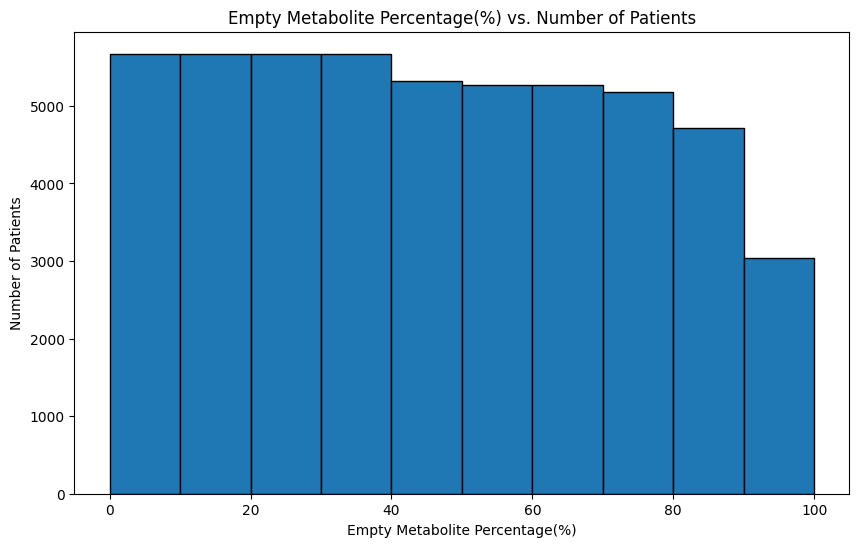

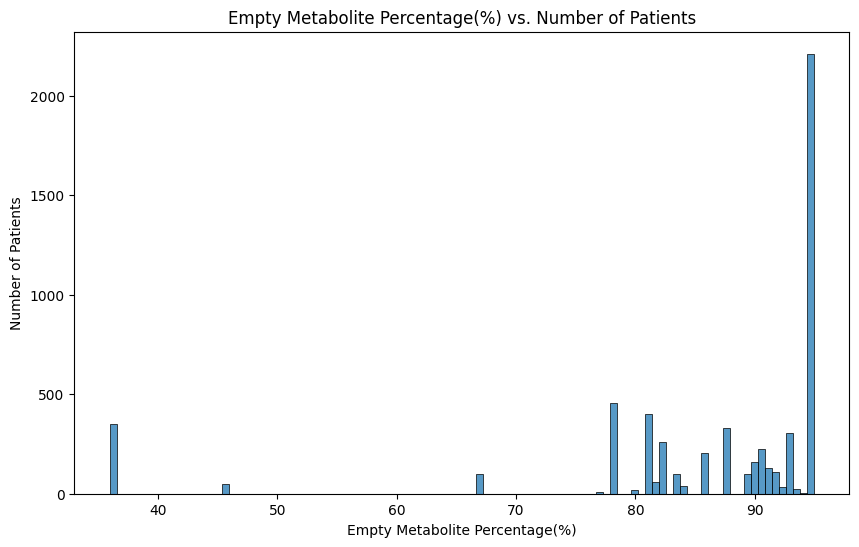

trp__L_c       5.023797
pro__L_m       7.985193
crtn_c        11.598801
orn__D_x      15.018509
urate_e       15.089018
                ...    
btcoa_m       99.118632
malthp_e      99.118632
xol27oh_m     99.118632
5g2oxpt_c     99.118632
wharachd_r    99.118632
Length: 954, dtype: float64


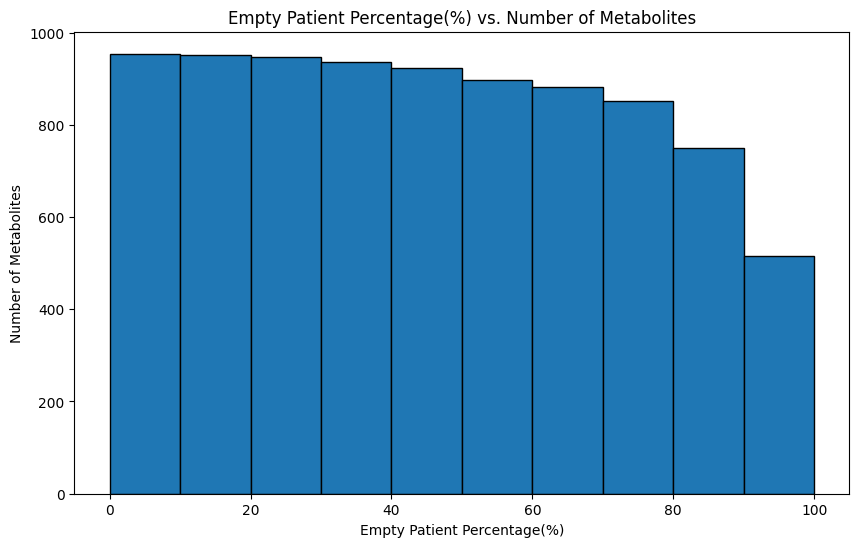

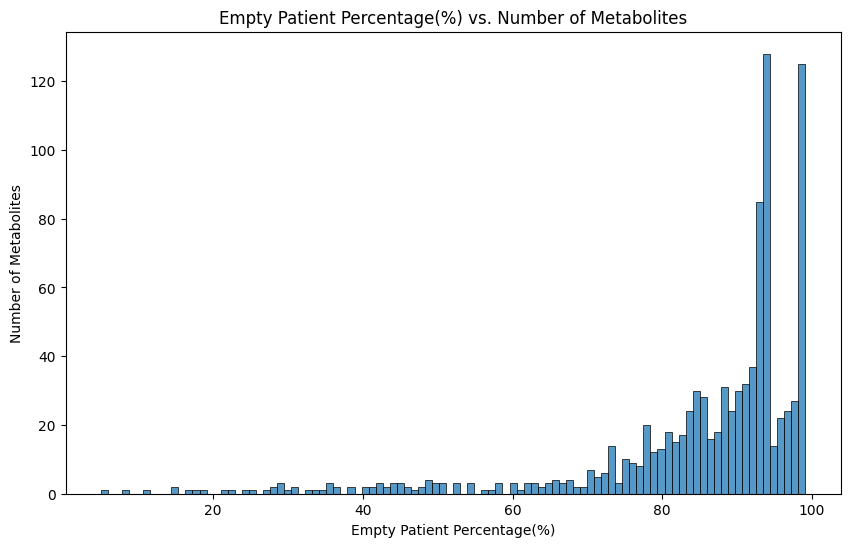

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

METABOLIGHTS_MAPPED_CSV_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "METABOLIGHTS_mapped.csv"
)

METABOLIGHTS_FILTERED_CSV_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "METABOLIGHTS_filtered.csv"
)

# Load the DataFrame
df = pd.read_csv(METABOLIGHTS_FILTERED_CSV_PATH)

# Info about DataFrame
num_rows = len(df)
num_cols = len(df.columns)
num_empty = df.isna().sum().sum()
total_cells = num_rows * num_cols
empty_percent = (num_empty / total_cells) * 100

print("########################## DF ##########################")
print(f"There are {num_cols} metabolites.")
print(f"There are {num_rows} patients.")
print(f"Total number of cells: {total_cells}.")
print(f"Total number of NA values: {num_empty}")
print(f"{empty_percent:.2f}% of DataFrame is empty.")


# Plot 1:
# x: Empty Metabolite Percentage
# y: Number of patients whose metabolite sets are at least x% empty
empty_metabolite_percentages = df.isna().mean(axis=1) * 100  # Rows(patients)
empty_metabolite_percentages = empty_metabolite_percentages.sort_values()

print(empty_metabolite_percentages)

# Define the number of bins (intervals)
num_bins = 10
# Create bins
bins = np.linspace(0, 100, num_bins + 1)
# Count the number of metabolites for each interval
counts, _ = np.histogram(empty_metabolite_percentages, bins)
# Calculate the cumulative counts in reverse order
cumulative_counts = counts[::-1].cumsum()[::-1]

plt.figure(figsize=(10, 6))
plt.hist(bins[:-1], bins, weights=cumulative_counts, edgecolor='black')
plt.xlabel("Empty Metabolite Percentage(%)")
plt.ylabel("Number of Patients")
plt.title("Empty Metabolite Percentage(%) vs. Number of Patients")
# plt.xticks(bins, [f"{int(bins[i])}-{int(bins[i+1])}%" for i in range(len(bins) - 1)], rotation=45)
plt.show()


# Plot 1 - Alternative:
plt.figure(figsize=(10, 6))
sns.histplot(data=empty_metabolite_percentages, bins=100)
plt.xlabel("Empty Metabolite Percentage(%)")
plt.ylabel("Number of Patients")
plt.title("Empty Metabolite Percentage(%) vs. Number of Patients")
plt.show()


# Plot 2:
# x: Empty Patient Percentage
# y: Number of Metabolites whose patient sets are at least x% empty
empty_patient_percentages = df.isna().mean(axis=0) * 100  # Columns(metabolites)
empty_patient_percentages = empty_patient_percentages.sort_values()

print(empty_patient_percentages)

# Count the number of metabolites for each interval
metabolite_counts, _ = np.histogram(empty_patient_percentages, bins)
# Calculate the cumulative counts in reverse order
metabolite_cumulative_counts = metabolite_counts[::-1].cumsum()[::-1]

plt.figure(figsize=(10, 6))
plt.hist(bins[:-1], bins, weights=metabolite_cumulative_counts, edgecolor='black')
plt.xlabel("Empty Patient Percentage(%)")
plt.ylabel("Number of Metabolites")
plt.title("Empty Patient Percentage(%) vs. Number of Metabolites")
plt.show()


# Plot 2 - Alternative:
plt.figure(figsize=(10, 6))
sns.histplot(data=empty_patient_percentages, bins=100)
plt.xlabel("Empty Patient Percentage(%)")
plt.ylabel("Number of Metabolites")
plt.title("Empty Patient Percentage(%) vs. Number of Metabolites")
plt.show()

## Inspect Single Study

In [ ]:
import os

import pandas as pd

STUDY_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolights", "03_mapped_human_only", "MTBLS71.csv"
)

# STUDY_2_PATH = os.path.join(
#     "datasets", "disease_datasets", "metabolights", "04_filtered_study_human_only", "MTBLS71.csv"
# )

# Load the DataFrame
df = pd.read_csv(STUDY_PATH)
# df2 = pd.read_csv(STUDY_2_PATH)

# Filter rows based on the number of columns
filtered_df = df[df.count(axis=1) >= 50]

filtered_df.count(axis=1)